# 1. Logisztikus regresszió modell

## Modell relevanciája

A logisztikus regresszió egy bináris klasszifikációs modell, ezért jól illeszkedik a prediktív karbantartási feladathoz, ahol a cél általában annak előrejelzése, hogy egy adott gépállapothoz tartozik-e meghibásodás vagy sem.

A célváltozó az adathalmazban két értéket vesz fel:

- 0 = nincs meghibásodás
- 1 = meghibásodás

A logisztikus regresszió előnye, hogy egyszerű, gyorsan tanítható, jól értelmezhető baseline modell. A modell nemcsak osztálycímkét ad vissza, hanem becsült valószínűséget is, amely megmutatja, hogy az adott megfigyelés mekkora valószínűséggel tartozik az 1-es osztályba.

## Elméleti háttér - áttekinteni

A logisztikus regresszió a bemeneti változók lineáris kombinációját használja:

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

Ezt a lineáris értéket a szigmoid függvény alakítja 0 és 1 közötti valószínűséggé:

σ(z) = 1 / (1 + e^(-z))

Ez azért fontos, mert bináris klasszifikáció esetén a modell kimenete valószínűségként értelmezhető. A tanult prezentáció alapján a logisztikus regresszió bináris célváltozó esetén alkalmazható, a szigmoid függvény pedig biztosítja, hogy a modell kimenete 0 és 1 közötti érték legyen. A logisztikus regresszió optimalizálása során a bináris keresztentrópia veszteségfüggvény használható, amely a becsült valószínűséget hasonlítja össze a valódi 0/1 címkével.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

## 2. Train és test csv beolvasás

In [ ]:
train_df = pd.read_csv("../../DataCleaning/train.csv")
test_df = pd.read_csv("../../DataCleaning/test.csv")

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,type_L,type_M,target
0,300.5,309.8,1345,62.7,153,9.3,1,0,0
1,303.7,312.4,1513,40.1,135,8.7,1,0,0
2,302.5,311.4,1559,37.6,209,8.9,1,0,0
3,295.6,306.3,1509,35.8,60,10.7,0,0,0
4,300.5,310.0,1358,60.4,102,9.5,0,0,0


## 3. X és y szétválasztása

- `X_train`: tanító magyarázó változók
- `y_train`: tanító célváltozó
- `X_test`: teszt magyarázó változók
- `y_test`: teszt célváltozó

In [8]:
target_col = "target"

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 8)
y_train shape: (8000,)
X_test shape: (2000, 8)
y_test shape: (2000,)


## 4. Osztályeloszlás ellenőrzése

In [10]:
def show_class_distribution(y, dataset_name):
    counts = y.value_counts().sort_index()
    ratios = y.value_counts(normalize = True).sort_index()*100

    dist_df = pd.DataFrame({
        "Count": counts,
        "Ratio (%)": ratios.round(2)
    })

    display(dist_df)

    return dist_df

train_dist = show_class_distribution(y_train, "Train")
test_dist = show_class_distribution(y_test, "Test")

,Count,Ratio (%)
target,,
0,7729,96.61
1,271,3.39


,Count,Ratio (%)
target,,
0,1932,96.6
1,68,3.4


## 5. Modellspecifikus előfeldolgozás meghatározása

A logisztikus regresszió lineáris modell, ezért érzékeny lehet a változók eltérő skálájára. Emiatt a numerikus változókat standardizáljuk.

A standardizálás célja, hogy a numerikus változók hasonló skálára kerüljenek:

- átlag ≈ 0
- szórás ≈ 1

Ezen numerikus oszlopokat most azonosítjuk.

A kategorikus változókat OneHotEncoder segítségével adattisztítás során numerikus formára alakítottuk és a 3 kategóriából egyet elhagytunk a multikollinearitás miatt, mivel a 2 kategóriaoszlopból egyértelműen meghatározható a 3. kategóriaoszlop értéke, így az oszlopok közti korreláció zavaró lehet a modell során.

In [19]:
numeric_columns = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
binary_features = ["type_L", "type_M"]

numeric_features = [
    col for col in numeric_columns
    if col not in binary_features
]
print("Numerikus változók száma:", len(numeric_features))
print(numeric_features)

selected_features = numeric_features + binary_features
print("Összes X_train oszlop:", X_train.shape[1])
print("Pipeline-ba bevont oszlopok:", len(selected_features))

Numerikus változók száma: 6
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k']
Összes X_train oszlop: 8
Pipeline-ba bevont oszlopok: 8


## 6. Pipeline létrehozása

A logisztikus regresszió modellhez pipeline-t hozunk létre, amely az előfeldolgozási lépéseket és a modellt egy közös folyamatba szervezi.

A pipeline-ban kétféle bemeneti változót kezelünk:

- **Folytonos numerikus változók:** ezeket `StandardScaler` segítségével standardizáljuk, mivel a logisztikus regresszió érzékeny lehet az eltérő skálájú változókra.
- **Bináris / dummy változók:** ezeket változatlanul továbbengedjük, mivel ezek már 0/1 formában szerepelnek az adathalmazban, ezért nem szükséges őket skálázni.

A pipeline végén egy logisztikus regressziós modell szerepel.

A pipeline használata azért előnyös, mert a keresztvalidáció során az előfeldolgozás minden foldban csak az adott tanító részen illeszkedik. Ez segít elkerülni az adatszivárgást, vagyis azt, hogy a validációs rész információi közvetetten bekerüljenek a tanítási folyamatba.

A `class_weight` paramétert ebben a lépésben még nem állítjuk be fixen. A későbbi hiperparaméter-keresés során kipróbáljuk a `None` és a `"balanced"` beállítást is, hogy a keresztvalidáció alapján dőljön el, szükséges-e az osztályegyensúlytalanság kezelése.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features)
    ],
    remainder="drop"
)

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logreg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 7. Keresztvalidáció beállítása

A modell értékeléséhez 5-fold stratifikált keresztvalidációt alkalmazunk.

A keresztvalidáció során a tanító adathalmazt több részre bontjuk. A modell több körben tanul és értékelődik úgy, hogy minden körben más rész szolgál validációs halmazként. Ez stabilabb képet ad a modell teljesítményéről, mintha csak egyetlen tanító-validációs bontást használnánk.

A `StratifiedKFold` használata azért indokolt, mert a célváltozó osztályarányait minden foldban igyekszik megtartani. Ez különösen fontos prediktív karbantartási feladat esetén, ahol a meghibásodásos esetek általában ritkábban fordulnak elő.

A keresztvalidációt kizárólag a `train.csv` adataiból képzett tanítóhalmazon végezzük. A `test.csv` adatait csak a végső modellértékelés során használjuk.

In [21]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## 8. Modell tanítása keresztvalidációval

Ebben a lépésben a logisztikus regressziós modellt 5-fold stratifikált keresztvalidációval értékeljük.

A keresztvalidáció célja, hogy stabilabb képet kapjunk a modell teljesítményéről, mintha csak egyetlen tanító-validációs bontást használnánk. A modell minden foldban a tanító részen tanul, majd az adott validációs részen kerül kiértékelésre.

Ebben a modellváltozatban nem végzünk hiperparaméter-keresést, hanem egy alap logisztikus regressziós modellt alkalmazunk. A cél egy egyszerű, jól értelmezhető baseline modell létrehozása, amely később összehasonlítható a komplexebb modellekkel, például döntési fával, Random Foresttel vagy XGBoosttal.

A keresztvalidáció során több teljesítménymutatót is számítunk:

- accuracy,
- precision,
- recall,
- F1-score,
- ROC-AUC.

Az F1-score és a recall különösen fontos prediktív karbantartási feladat esetén, mert a meghibásodásos esetek felismerése gyakran fontosabb, mint az összesített accuracy érték.

In [22]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    estimator=logreg_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=True
)

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Train mean": [
        cv_results["train_accuracy"].mean(),
        cv_results["train_precision"].mean(),
        cv_results["train_recall"].mean(),
        cv_results["train_f1"].mean(),
        cv_results["train_roc_auc"].mean()
    ],
    "Validation mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Validation std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary = cv_summary.round(4)
display(cv_summary)

,Metric,Train mean,Validation mean,Validation std
0,Accuracy,0.9704,0.9705,0.0014
1,Precision,0.7404,0.7597,0.0995
2,Recall,0.1965,0.2030,0.0314
3,F1-score,0.3105,0.3166,0.0337
4,ROC-AUC,0.8977,0.8946,0.0165


## 9. Keresztvalidációs eredmények értékelése

A keresztvalidációs eredmények alapján a logisztikus regressziós modell stabilan teljesített, mivel a train és validation értékek nagyon közel vannak egymáshoz. Ez arra utal, hogy a modell nem mutat jelentős túltanulást: a tanító és validációs foldokon mért teljesítmény hasonló.

Az accuracy értéke mind a train, mind a validation adatokon körülbelül 0.97, ami első ránézésre nagyon jó eredménynek tűnik. Ugyanakkor prediktív karbantartási feladatoknál az accuracy önmagában félrevezető lehet, mivel a meghibásodásos esetek általában ritkábban fordulnak elő. Ha a negatív, vagyis nem meghibásodásos osztály van túlsúlyban, akkor egy modell magas accuracy-t érhet el akkor is, ha a hibás eseteket csak kis arányban ismeri fel.

A precision értéke a validációs eredmények alapján 0.7597, vagyis amikor a modell meghibásodást jelez, akkor az esetek körülbelül 76%-ában helyesen dönt. Ez viszonylag jó eredmény, mert azt mutatja, hogy a pozitív jelzések nagy része valóban meghibásodáshoz kapcsolódik.

A recall értéke ugyanakkor csak 0.2030, ami azt jelenti, hogy a modell a valódi meghibásodásoknak csupán körülbelül 20%-át ismeri fel. Ez prediktív karbantartási szempontból gyenge pont, mivel a cél jellemzően az lenne, hogy minél több potenciális meghibásodást előre azonosítsunk. Az alacsony recall alapján a modell sok tényleges meghibásodást nem jelez előre.

Az F1-score értéke 0.3166, ami a precision és recall közötti egyensúlyt mutatja. Mivel a recall alacsony, az F1-score is viszonylag alacsony lett. Ez azt jelzi, hogy bár a modell pozitív jelzései viszonylag pontosak, túl kevés pozitív esetet azonosít.

A ROC-AUC értéke 0.8946, ami kifejezetten jó osztályszétválasztó képességre utal. Ez azt jelenti, hogy a modell valószínűségi szinten jól képes rangsorolni a meghibásodásos és nem meghibásodásos eseteket. Emiatt a modell nem tekinthető rossznak, azonban az alapértelmezett döntési küszöb mellett túl konzervatívan jelzi a meghibásodásokat.

Összességében a logisztikus regresszió jó baseline modellnek tekinthető: stabil, nem mutat jelentős túltanulást, és a ROC-AUC alapján jól elkülöníti az osztályokat. Ugyanakkor a recall alacsony értéke miatt önmagában nem lenne ideális végső prediktív karbantartási modellként. A későbbi fejlesztés során érdemes lehet a döntési küszöb módosítását, az osztálysúlyozás alkalmazását vagy komplexebb modellek, például Random Forest, Gradient Boosting vagy XGBoost kipróbálását vizsgálni.

## 10. Végső modell betanítása a teljes train adaton

A keresztvalidációs értékelés után a végső logisztikus regressziós modellt a teljes tanító adathalmazon tanítjuk be.

A keresztvalidáció során a modell több különböző train-validation bontáson került kiértékelésre, így képet kaptunk arról, hogy a modell mennyire stabilan teljesít. Mivel ebben a verzióban nem végzünk hiperparaméter-keresést, nem választunk külön „legjobb” modellbeállítást, hanem az előre definiált logisztikus regressziós pipeline-t tanítjuk újra a teljes train adaton.

Erre azért van szükség, mert a végső modellnek érdemes az összes rendelkezésre álló tanító adatból tanulnia. Ezt követően a modell teljesítményét a független teszthalmazon értékeljük.

In [23]:
final_logreg_model = logreg_pipeline.fit(X_train, y_train)

final_logreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 11. Végső tesztelés a test.csv-n

A végső logisztikus regressziós modellt a független teszthalmazon értékeljük.

A `test.csv` adatait nem használtuk a keresztvalidáció során, és nem használtuk a modell betanításához sem. Ezért alkalmas arra, hogy objektív képet adjon arról, hogyan teljesítene a modell új, korábban nem látott adatokon.

Első lépésben az alapértelmezett 0.5-ös döntési küszöbbel készítünk predikciót. A logisztikus regresszió emellett valószínűségi becslést is ad, amely megmutatja, hogy az adott megfigyelés mekkora valószínűséggel tartozik a pozitív, vagyis meghibásodásos osztályba.

In [ ]:
y_test_pred = final_logreg_model.predict(X_test)
y_test_proba = final_logreg_model.predict_proba(X_test)[:, 1]

print("Prediktált osztályok első 10 eleme:")
print(y_test_pred[:10])

print("\nPrediktált meghibásodási valószínűségek első 10 eleme:")
print(y_test_proba[:10])


Prediktált osztályok első 10 eleme:
[1 0 0 0 0 0 0 0 0 0]

Prediktált meghibásodási valószínűségek első 10 eleme:
[6.09057954e-01 3.03233640e-02 5.14586278e-02 3.12945636e-04
 1.91936930e-01 3.94775463e-02 8.41018149e-02 5.99930957e-03
 1.77069489e-03 6.43077607e-02]
Osztályok sorrendje a modellben:
[0 1]


## 11. Confusion matrix készítése

A confusion matrix megmutatja, hogy a modell a teszthalmazon hány esetben döntött helyesen vagy hibásan.

A mátrix négy fő eleme:

- **TN:** valódi negatív eset, amelyet a modell negatívnak jelzett,
- **FP:** valódi negatív eset, amelyet a modell tévesen pozitívnak jelzett,
- **FN:** valódi pozitív eset, amelyet a modell tévesen negatívnak jelzett,
- **TP:** valódi pozitív eset, amelyet a modell pozitívnak jelzett.

Prediktív karbantartási feladatnál különösen fontos az **FN** érték, mert ez azt jelenti, hogy a modell nem ismert fel egy valódi meghibásodást.

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Valós 0 - nincs meghibásodás", "Valós 1 - meghibásodás"],
    columns=["Prediktált 0 - nincs meghibásodás", "Prediktált 1 - meghibásodás"]
)

display(confusion_matrix_df)

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

,Prediktált 0 - nincs meghibásodás,Prediktált 1 - meghibásodás
Valós 0 - nincs meghibásodás,1927,5
Valós 1 - meghibásodás,61,7


TN: 1927
FP: 5
FN: 61
TP: 7


## 12. Teljesítménymutatók számítása

A modell teljesítményét több mutató alapján értékeljük.

Az **accuracy** azt mutatja meg, hogy az összes eset mekkora részét sorolta be helyesen a modell. Osztályegyensúlytalanság esetén azonban ez önmagában félrevezető lehet.

Ezért további mutatókat is számítunk:

- **Precision:** a pozitívnak jelzett esetek közül mennyi volt valóban pozitív.
- **Recall / TPR:** a valódi pozitív esetek közül mennyit ismert fel a modell.
- **Specificity / TNR:** a valódi negatív esetek közül mennyit ismert fel helyesen a modell.
- **FPR:** a valódi negatív esetek közül mennyit jelzett tévesen pozitívnak.
- **F1-score:** a precision és recall harmonikus átlaga.
- **ROC-AUC:** a modell általános osztályszétválasztó képessége.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
fpr_value = fp / (fp + tn) if (fp + tn) != 0 else 0

roc_auc = roc_auc_score(y_test, y_test_proba)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / TPR",
        "Specificity / TNR",
        "FPR",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        fpr_value,
        f1,
        roc_auc
    ]
})

metrics_df["Value"] = metrics_df["Value"].round(4)
display(metrics_df)

,Metric,Value
0,Accuracy,0.9670
1,Precision,0.5833
2,Recall / TPR,0.1029
3,Specificity / TNR,0.9974
4,FPR,0.0026
5,F1-score,0.1750
6,ROC-AUC,0.9001


## 13. ROC görbe és AUC

A ROC görbe a **True Positive Rate** és a **False Positive Rate** kapcsolatát mutatja különböző döntési küszöbök mellett.

A **True Positive Rate** megegyezik a recall értékkel, vagyis azt mutatja meg, hogy a modell a valódi pozitív esetek mekkora részét ismerte fel helyesen.

A **False Positive Rate** azt mutatja meg, hogy a modell a valódi negatív esetek mekkora részét jelölte tévesen pozitívnak.

Az **AUC** érték a modell általános osztályszétválasztó képességét foglalja össze. Minél közelebb van az AUC érték 1-hez, annál jobb a modell szeparációs képessége. A 0.5 körüli érték véletlenszerű döntéshez közeli teljesítményt jelent.

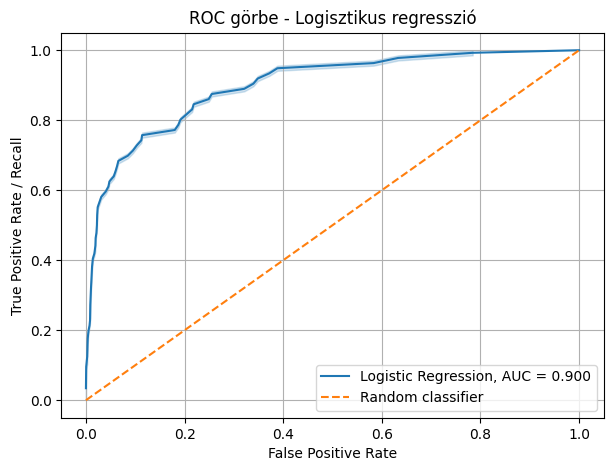

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr,
    "Threshold": thresholds
})

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=roc_df,
    x="False Positive Rate",
    y="True Positive Rate",
    label=f"Logistic Regression, AUC = {roc_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title("ROC görbe - Logisztikus regresszió")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
plt.grid(True)
plt.show()

## 14. Döntési küszöb módosítása

A logisztikus regresszió alapértelmezés szerint 0.5-ös döntési küszöböt használ. Ez azt jelenti, hogy a modell akkor sorol egy megfigyelést a pozitív, vagyis meghibásodásos osztályba, ha a becsült meghibásodási valószínűség legalább 50%.

Az alapmodell teszteredményei alapján a recall értéke alacsony volt, vagyis a modell a valódi meghibásodások jelentős részét nem ismerte fel. Prediktív karbantartási feladat esetén ez problémát jelenthet, mivel a cél gyakran az, hogy minél több potenciális meghibásodást előre jelezzünk.

Ezért több alacsonyabb döntési küszöböt is kipróbálunk. A küszöb csökkentése általában növeli a recall értéket, viszont csökkentheti a precision értéket, mivel több téves pozitív riasztás keletkezhet.

In [ ]:
thresholds_to_try = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]

threshold_results = []
confusion_matrices = {}

for threshold in thresholds_to_try:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    tn_t, fp_t, fn_t, tp_t = cm_threshold.ravel()
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall / TPR": recall_score(y_test, y_pred_threshold, zero_division=0),
        "Specificity / TNR": tn_t / (tn_t + fp_t) if (tn_t + fp_t) != 0 else 0,
        "FPR": fp_t / (fp_t + tn_t) if (fp_t + tn_t) != 0 else 0,
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_test_proba),
        "TP": tp_t,
        "FP": fp_t,
        "FN": fn_t,
        "TN": tn_t
    })
    
    confusion_matrices[threshold] = cm_threshold

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df = threshold_results_df.round(4)

display(threshold_results_df)


,Threshold,Accuracy,Precision,Recall / TPR,Specificity / TNR,FPR,F1-score,ROC-AUC,TP,FP,FN,TN
0,0.50,0.9670,0.5833,0.1029,0.9974,0.0026,0.1750,0.9001,7,5,61,1927
1,0.40,0.9680,0.5833,0.2059,0.9948,0.0052,0.3043,0.9001,14,10,54,1922
2,0.30,0.9675,0.5349,0.3382,0.9896,0.0104,0.4144,0.9001,23,20,45,1912
3,0.25,0.9655,0.4912,0.4118,0.9850,0.0150,0.4480,0.9001,28,29,40,1903
4,0.20,0.9615,0.4384,0.4706,0.9788,0.0212,0.4539,0.9001,32,41,36,1891
5,0.15,0.9575,0.4105,0.5735,0.9710,0.0290,0.4785,0.9001,39,56,29,1876
6,0.10,0.9375,0.3007,0.6324,0.9482,0.0518,0.4076,0.9001,43,100,25,1832


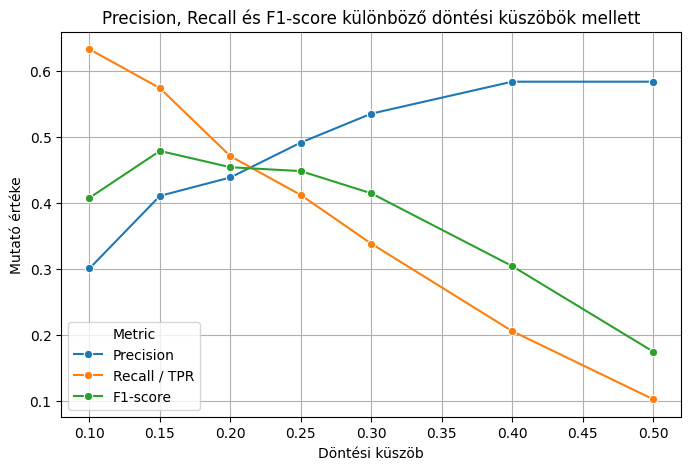

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

threshold_plot_df = threshold_results_df.melt(
    id_vars="Threshold",
    value_vars=["Precision", "Recall / TPR", "F1-score"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=threshold_plot_df,
    x="Threshold",
    y="Value",
    hue="Metric",
    marker="o"
)

plt.title("Precision, Recall és F1-score különböző döntési küszöbök mellett")
plt.xlabel("Döntési küszöb")
plt.ylabel("Mutató értéke")
plt.grid(True)
plt.show()

## 15. Végső döntési küszöb kiválasztása

A különböző döntési küszöbök összehasonlítása alapján a **0.15-ös thresholdot** választottuk végső döntési küszöbként.

Az alapértelmezett 0.5-ös küszöb mellett a modell recall értéke alacsony volt, vagyis a valódi meghibásodások nagy részét nem ismerte fel. Prediktív karbantartási feladatban ez problémát jelenthet, mivel a cél a potenciális meghibásodások minél korábbi azonosítása.

A 0.15-ös küszöb választását az indokolja, hogy a vizsgált threshold értékek közül ennél volt a legmagasabb az F1-score, vagyis ez adta a legjobb kompromisszumot a precision és recall között. Ennél a küszöbnél a recall jelentősen javult, így a modell több valódi meghibásodást azonosított.

A küszöb csökkentésével ugyanakkor nőtt a téves pozitív jelzések száma is. Ez azt jelenti, hogy a modell több esetben jelezhet tévesen meghibásodást, azonban prediktív karbantartási környezetben ez a kompromisszum elfogadható lehet, ha a valódi meghibásodások kihagyásának kockázata nagyobb, mint a többlet riasztások kezelése.

In [35]:
selected_threshold = 0.15

y_test_pred_threshold = (y_test_proba >= selected_threshold).astype(int)

cm_threshold = confusion_matrix(y_test, y_test_pred_threshold)

tn_threshold, fp_threshold, fn_threshold, tp_threshold = cm_threshold.ravel()

confusion_matrix_threshold_df = pd.DataFrame(
    cm_threshold,
    index=["Valós 0 - nincs meghibásodás", "Valós 1 - meghibásodás"],
    columns=["Prediktált 0 - nincs meghibásodás", "Prediktált 1 - meghibásodás"]
)

display(confusion_matrix_threshold_df)


,Prediktált 0 - nincs meghibásodás,Prediktált 1 - meghibásodás
Valós 0 - nincs meghibásodás,1876,56
Valós 1 - meghibásodás,29,39


## 16. Összegzés és következtetések

A logisztikus regressziós modell elkészítése során egy strukturált, lépésről lépésre felépített modellépítési folyamatot követtünk. A cél egy olyan baseline klasszifikációs modell létrehozása volt, amely képes előre jelezni, hogy egy adott gépállapot meghibásodáshoz vezet-e vagy sem.

Első lépésként bemutattuk, hogy a logisztikus regresszió miért releváns a prediktív karbantartási feladatban. Mivel a célváltozó bináris, vagyis két lehetséges értéket vehet fel, a logisztikus regresszió megfelelő kiindulási modellnek tekinthető. A modell előnye, hogy egyszerű, gyorsan tanítható, jól értelmezhető, és valószínűségi kimenetet is ad.

Ezután beolvastuk a korábban megtisztított `train.csv` és `test.csv` fájlokat, majd különválasztottuk a magyarázó változókat és a célváltozót. Ellenőriztük az osztályeloszlást is, mivel prediktív karbantartási problémáknál gyakori, hogy a meghibásodásos esetek ritkábban fordulnak elő. Ez azért fontos, mert osztályegyensúlytalanság esetén az accuracy önmagában félrevezető lehet.

A modellspecifikus előfeldolgozás során meghatároztuk, hogy mely változókat szükséges skálázni. Mivel a logisztikus regresszió érzékeny lehet az eltérő skálájú változókra, a folytonos numerikus változókat `StandardScaler` segítségével standardizáltuk. A bináris / dummy változókat nem skáláztuk, hanem változatlanul továbbengedtük a modellbe.

Ezt követően létrehoztunk egy pipeline-t, amely egy folyamatba szervezte az előfeldolgozást és a logisztikus regressziós modellt. A pipeline használata azért volt fontos, mert így a keresztvalidáció során az előfeldolgozás minden foldban csak az adott tanító részen illeszkedett, ezzel csökkentve az adatszivárgás kockázatát.

A modell teljesítményét először 5-fold stratifikált keresztvalidációval értékeltük. A stratifikált bontás biztosította, hogy az egyes foldokban a célváltozó osztályarányai hasonlóak maradjanak. Ebben a modellváltozatban nem végeztünk hiperparaméter-keresést, hanem egy alap logisztikus regressziós modellt használtunk baseline modellként. A keresztvalidáció célja ezért nem a legjobb hiperparaméterek kiválasztása volt, hanem annak vizsgálata, hogy a választott modell mennyire stabilan teljesít különböző tanító-validációs bontásokon.

A keresztvalidációs eredmények alapján a modell nem mutatott jelentős túltanulást, mivel a train és validation eredmények közel voltak egymáshoz. Ugyanakkor már itt látható volt, hogy a modell recall értéke alacsony, vagyis a valódi meghibásodásos esetek jelentős részét nem ismeri fel.

A keresztvalidáció után a végső logisztikus regressziós modellt a teljes tanító adathalmazon tanítottuk be, majd a független teszthalmazon értékeltük. Az alapértelmezett 0.5-ös döntési küszöb mellett a modell magas accuracy és specificity értéket ért el, azonban a recall nagyon alacsony maradt. Ez azt jelentette, hogy a modell jól felismerte a nem meghibásodásos eseteket, de sok valódi meghibásodást nem jelzett előre.

A ROC-AUC érték ugyanakkor jó osztályszétválasztó képességre utalt. Ez azt mutatta, hogy a modell valószínűségi szinten képes különbséget tenni a meghibásodásos és nem meghibásodásos esetek között, viszont az alapértelmezett 0.5-ös döntési küszöb túl szigorú volt.

Ezért a következő döntési pont a döntési küszöb módosítása volt. Több threshold értéket is kipróbáltunk, és megvizsgáltuk, hogyan változik a precision, recall, F1-score, valamint a confusion matrix elemei. A küszöb csökkentésével a modell több esetet sorolt a meghibásodásos osztályba, ennek következtében javult a recall, ugyanakkor nőtt a téves pozitív jelzések száma.

A kipróbált küszöbök alapján a 0.15-ös thresholdot választottuk végső döntési küszöbként. Ennél az értéknél volt a legmagasabb az F1-score, tehát ez adta a legjobb kompromisszumot a precision és recall között. A 0.15-ös küszöb alkalmazásával a modell lényegesen több valódi meghibásodást ismert fel, mint az alapértelmezett 0.5-ös küszöb mellett.

Összességében a logisztikus regresszió megfelelő baseline modellnek bizonyult. Előnye, hogy egyszerű, gyors, jól értelmezhető, és a döntési küszöb módosításával jobban igazítható a prediktív karbantartási célhoz. Ugyanakkor a modell korlátja, hogy alapvetően lineáris döntési határt tanul, ezért komplexebb, nemlineáris mintázatok felismerésében gyengébb lehet. Emiatt a későbbi modellezési lépésekben érdemes más modelleket is kipróbálni, majd ezek eredményeit összehasonlítani a logisztikus regressziós baseline modell teljesítményével.

## 17. Mentés

In [36]:
threshold_results_df.to_csv(
    "logreg_threshold_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Threshold eredménytábla elmentve a jelenlegi mappába:")
print("logreg_threshold_comparison.csv")

Threshold eredménytábla elmentve a jelenlegi mappába:
logreg_threshold_comparison.csv
